In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install timm scikit-learn -q

In [ ]:
import os
import time
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Check if GPU is available, otherwise fall back to CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training configuration
BATCH_SIZE  = 32    # number of images processed at once
IMG_SIZE    = 224   # standard input size for pretrained models
NUM_CLASSES = 28     # sub-classes of main 5 class bottle, canister, cans, cardboard, detergent
EPOCHS      = 20    # number of full passes through the training data
LR          = 1e-4  # learning rate - how fast the model updates

print("Using device:", DEVICE)

Using device: cuda


In [ ]:
# Augmentation is applied on-the-fly during training only
# This means every epoch the model sees slightly different versions
# of the same image - helps prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# No augmentation for validation - we want real world performance
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms ready!")

Transforms ready!


In [ ]:
class WarpDataset(Dataset):
  # Custom dataset loader for WaRP-C.
    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples   = []
  # 28 SUBCLASS names as our labels
        self.classes = sorted([
            subclass
            for category in os.listdir(root)
            for subclass in os.listdir(os.path.join(root, category))
        ])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        for category in os.listdir(root):
            category_path = os.path.join(root, category)
            for subclass in os.listdir(category_path):
                subclass_path = os.path.join(category_path, subclass)
                for img_file in os.listdir(subclass_path):
                    self.samples.append((
                        os.path.join(subclass_path, img_file),
                        self.class_to_idx[subclass]  # label = subclass now!
                    ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
# Paths to the preprocessed dataset shared by our team
# Dataset is already split into train, val and test - no splitting needed
TRAIN_PATH = '/content/drive/MyDrive/AML Project/WaRP-C-preprocessed/train'
VAL_PATH   = '/content/drive/MyDrive/AML Project/WaRP-C-preprocessed/val'
TEST_PATH  = '/content/drive/MyDrive/AML Project/WaRP-C-preprocessed/test'

# Load each split with appropriate transforms
train_dataset = WarpDataset(TRAIN_PATH, transform=train_transform)
val_dataset   = WarpDataset(VAL_PATH,   transform=val_transform)
test_dataset  = WarpDataset(TEST_PATH,  transform=val_transform)

# CLASS WEIGHTS
# 28 classes have very unequal number of images
# WeightedRandomSampler makes sure every class is seen equally during training
targets        = [label for _, label in train_dataset.samples]
class_counts   = np.bincount(targets)
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

# Train loader uses sampler instead of shuffle
# Val and test loaders don't need sampler - we want real distribution
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"Classes:      {train_dataset.classes}")
print(f"Train images: {len(train_dataset)}")
print(f"Val images:   {len(val_dataset)}")
print(f"Test images:  {len(test_dataset)}")

Classes:      ['bottle-blue', 'bottle-blue-full', 'bottle-blue5l', 'bottle-blue5l-full', 'bottle-dark', 'bottle-dark-full', 'bottle-green', 'bottle-green-full', 'bottle-milk', 'bottle-milk-full', 'bottle-multicolor', 'bottle-multicolorv-full', 'bottle-oil', 'bottle-oil-full', 'bottle-transp', 'bottle-transp-full', 'bottle-yogurt', 'canister', 'cans', 'detergent-box', 'detergent-color', 'detergent-transparent', 'detergent-white', 'glass-dark', 'glass-green', 'glass-transp', 'juice-cardboard', 'milk-cardboard']
Train images: 7072
Val images:   1765
Test images:  1551


In [ ]:
# Dictionary to store results for all models so we can compare later
all_results = {}

def train_model(model_name):
    """
    Trains a pretrained model on our waste classification dataset.
    Uses transfer learning - the model already knows general features
    from ImageNet, we just fine-tune it for our 5 waste classes.

    Args:
        model_name: name of the model from timm library

    Returns:
        trained model
    """

    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    # Load pretrained model and replace final layer for our 5 classes
    model = timm.create_model(model_name, pretrained=True, num_classes=NUM_CLASSES)
    model = model.to(DEVICE)

    # Calculate model size in MB (number of parameters x 4 bytes per float)
    model_size = sum(p.numel() for p in model.parameters()) * 4 / (1024 ** 2)

    # AdamW optimizer works well with transformers and CNNs
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    # CosineAnnealingLR gradually reduces learning rate during training
    # this helps the model converge to a better solution
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # CrossEntropyLoss is standard for multi-class classification
    # label_smoothing=0.1 prevents overconfidence and improves generalisation
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    train_losses = []
    val_accs     = []
    best_acc     = 0.0
    start_time   = time.time()

    for epoch in range(EPOCHS):

        #Training phase
        model.train()
        total_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()           # clear previous gradients
            outputs = model(imgs)           # forward pass
            loss    = criterion(outputs, labels)  # calculate loss
            loss.backward()                 # backward pass
            optimizer.step()               # update weights
            total_loss += loss.item()

        # Update learning rate after each epoch
        scheduler.step()

        # Validation phase
        # We don't update weights here, just check accuracy
        model.eval()
        correct = 0
        total   = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                preds   = outputs.argmax(1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)

        acc        = correct / total
        epoch_loss = total_loss / len(train_loader)

        train_losses.append(epoch_loss)
        val_accs.append(acc)

        # Save the best model weights to Drive
        if acc > best_acc:
            best_acc = acc
            torch.save(
                model.state_dict(),
                f'/content/drive/MyDrive/AML Project/{model_name}_best.pth'
            )

        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.3f} | Val Acc: {acc*100:.2f}")

    # Total training time
    total_time = time.time() - start_time

    #Final evaluation on validation set and Collect all predictions, true labels and probabilities
    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs    = imgs.to(DEVICE)
            logits  = model(imgs)
            probs   = torch.softmax(logits, dim=1).cpu().numpy()
            preds   = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    # Calculate metrics
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall    = recall_score(all_labels, all_preds, average='weighted',    zero_division=0)
    f1        = f1_score(all_labels, all_preds, average='weighted',        zero_division=0)

    # AUC uses probability scores, not just predictions
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
    except Exception as e:
        auc = 0.0
        print(f"AUC could not be calculated: {e}")

    # Save all results for comparison later
    all_results[model_name] = {
        "train_losses": train_losses,
        "val_accs":     val_accs,
        "best_acc":     best_acc,
        "precision":    precision,
        "recall":       recall,
        "f1":           f1,
        "auc":          auc,
        "time":         total_time,
        "size_mb":      model_size,
        "preds":        all_preds,
        "labels":       all_labels,
    }

    # Print summary
    print(f"\n{'='*50}")
    print(f"         MODEL PERFORMANCE SUMMARY")
    print(f"{'='*50}")
    print(f"Model Name     : {model_name}")
    print(f"Training Loss  : {train_losses[-1]:.4f} (final epoch)")
    print(f"Val Accuracy   : {best_acc*100:.2f}%")
    print(f"Precision      : {precision*100:.4f}")
    print(f"Recall         : {recall*100:.4f}")
    print(f"F1-Score       : {f1*100:.4f}")
    print(f"AUC            : {auc*100:.4f}")
    print(f"Training Time  : {total_time/60:.1f} minutes")
    print(f"Model Size     : {model_size:.1f} MB")
    print(f"{'='*50}")

    return model

In [ ]:
# Training EfficientNet-B0 to test the pipeline
model1 = train_model("efficientnet_b0")


Training: efficientnet_b0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 1/20 | Loss: 2.536 | Val Acc: 48.16
Epoch 2/20 | Loss: 1.571 | Val Acc: 56.66
Epoch 3/20 | Loss: 1.344 | Val Acc: 63.12
Epoch 4/20 | Loss: 1.188 | Val Acc: 65.10
Epoch 5/20 | Loss: 1.114 | Val Acc: 65.55
Epoch 6/20 | Loss: 1.038 | Val Acc: 68.61
Epoch 7/20 | Loss: 0.980 | Val Acc: 68.78
Epoch 8/20 | Loss: 0.930 | Val Acc: 70.03
Epoch 9/20 | Loss: 0.897 | Val Acc: 71.16
Epoch 10/20 | Loss: 0.879 | Val Acc: 71.50
Epoch 11/20 | Loss: 0.864 | Val Acc: 71.27
Epoch 12/20 | Loss: 0.841 | Val Acc: 71.16
Epoch 13/20 | Loss: 0.826 | Val Acc: 71.39
Epoch 14/20 | Loss: 0.818 | Val Acc: 71.84
Epoch 15/20 | Loss: 0.811 | Val Acc: 71.95
Epoch 16/20 | Loss: 0.800 | Val Acc: 72.01
Epoch 17/20 | Loss: 0.804 | Val Acc: 72.41
Epoch 18/20 | Loss: 0.797 | Val Acc: 72.41
Epoch 19/20 | Loss: 0.793 | Val Acc: 72.46
Epoch 20/20 | Loss: 0.792 | Val Acc: 72.18

         MODEL PERFORMANCE SUMMARY
Model Name     : efficientnet_b0
Training Loss  : 0.7925 (final epoch)
Val Accuracy   : 72.46%
Precision      : 7

In [ ]:
# Final evaluation on unseen test data

def evaluate_on_test(model, model_name):

    # Load the best saved weights for this model
    model.load_state_dict(torch.load(
        f'/content/drive/MyDrive/AML Project/{model_name}_best.pth'
    ))
    model.eval()

    all_test_preds  = []
    all_test_labels = []
    all_test_probs  = []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs   = imgs.to(DEVICE)
            logits = model(imgs)

            # Convert raw scores to probabilities
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = logits.argmax(1).cpu().numpy()

            all_test_preds.extend(preds)
            all_test_labels.extend(labels.numpy())
            all_test_probs.extend(probs)

    all_test_preds  = np.array(all_test_preds)
    all_test_labels = np.array(all_test_labels)
    all_test_probs  = np.array(all_test_probs)

    # Calculate all metrics on test set
    precision = precision_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)
    recall    = recall_score(all_test_labels, all_test_preds, average='weighted',    zero_division=0)
    f1        = f1_score(all_test_labels, all_test_preds, average='weighted',        zero_division=0)

    try:
        auc = roc_auc_score(all_test_labels, all_test_probs, multi_class='ovr', average='weighted')
    except:
        auc = 0.0

    test_acc = np.sum(all_test_labels == all_test_preds) / len(all_test_labels) * 100

    print(f"\n{'='*50}")
    print(f"   FINAL TEST RESULTS - {model_name}")
    print(f"{'='*50}")
    print(f"Test Accuracy  : {test_acc:.2f}%")
    print(f"Precision      : {precision*100:.2f}%")
    print(f"Recall         : {recall*100:.2f}%")
    print(f"F1-Score       : {f1*100:.2f}%")
    print(f"AUC            : {auc*100:.2f}%")
    print(f"{'='*50}")

    # Per class breakdown - shows which classes are hardest
    print(f"\nPer-class Report:")
    print(classification_report(
        all_test_labels,
        all_test_preds,
        target_names=test_dataset.classes
    ))

    return all_test_preds, all_test_labels

# Run test evaluation for EfficientNet
test_preds1, test_labels1 = evaluate_on_test(model1, "efficientnet_b0")


   FINAL TEST RESULTS - efficientnet_b0
Test Accuracy  : 70.73%
Precision      : 70.46%
Recall         : 70.73%
F1-Score       : 70.17%
AUC            : 96.50%

Per-class Report:
                         precision    recall  f1-score   support

            bottle-blue       0.76      0.67      0.71       104
       bottle-blue-full       0.73      0.70      0.71        43
          bottle-blue5l       0.67      0.81      0.73        72
     bottle-blue5l-full       0.70      0.79      0.75        24
            bottle-dark       0.79      0.87      0.83        95
       bottle-dark-full       0.68      0.76      0.72        34
           bottle-green       0.79      0.93      0.86        74
      bottle-green-full       0.67      0.85      0.75        34
            bottle-milk       0.54      0.63      0.58        57
       bottle-milk-full       0.68      0.81      0.74        21
      bottle-multicolor       0.50      0.29      0.36        28
bottle-multicolorv-full       0.70     

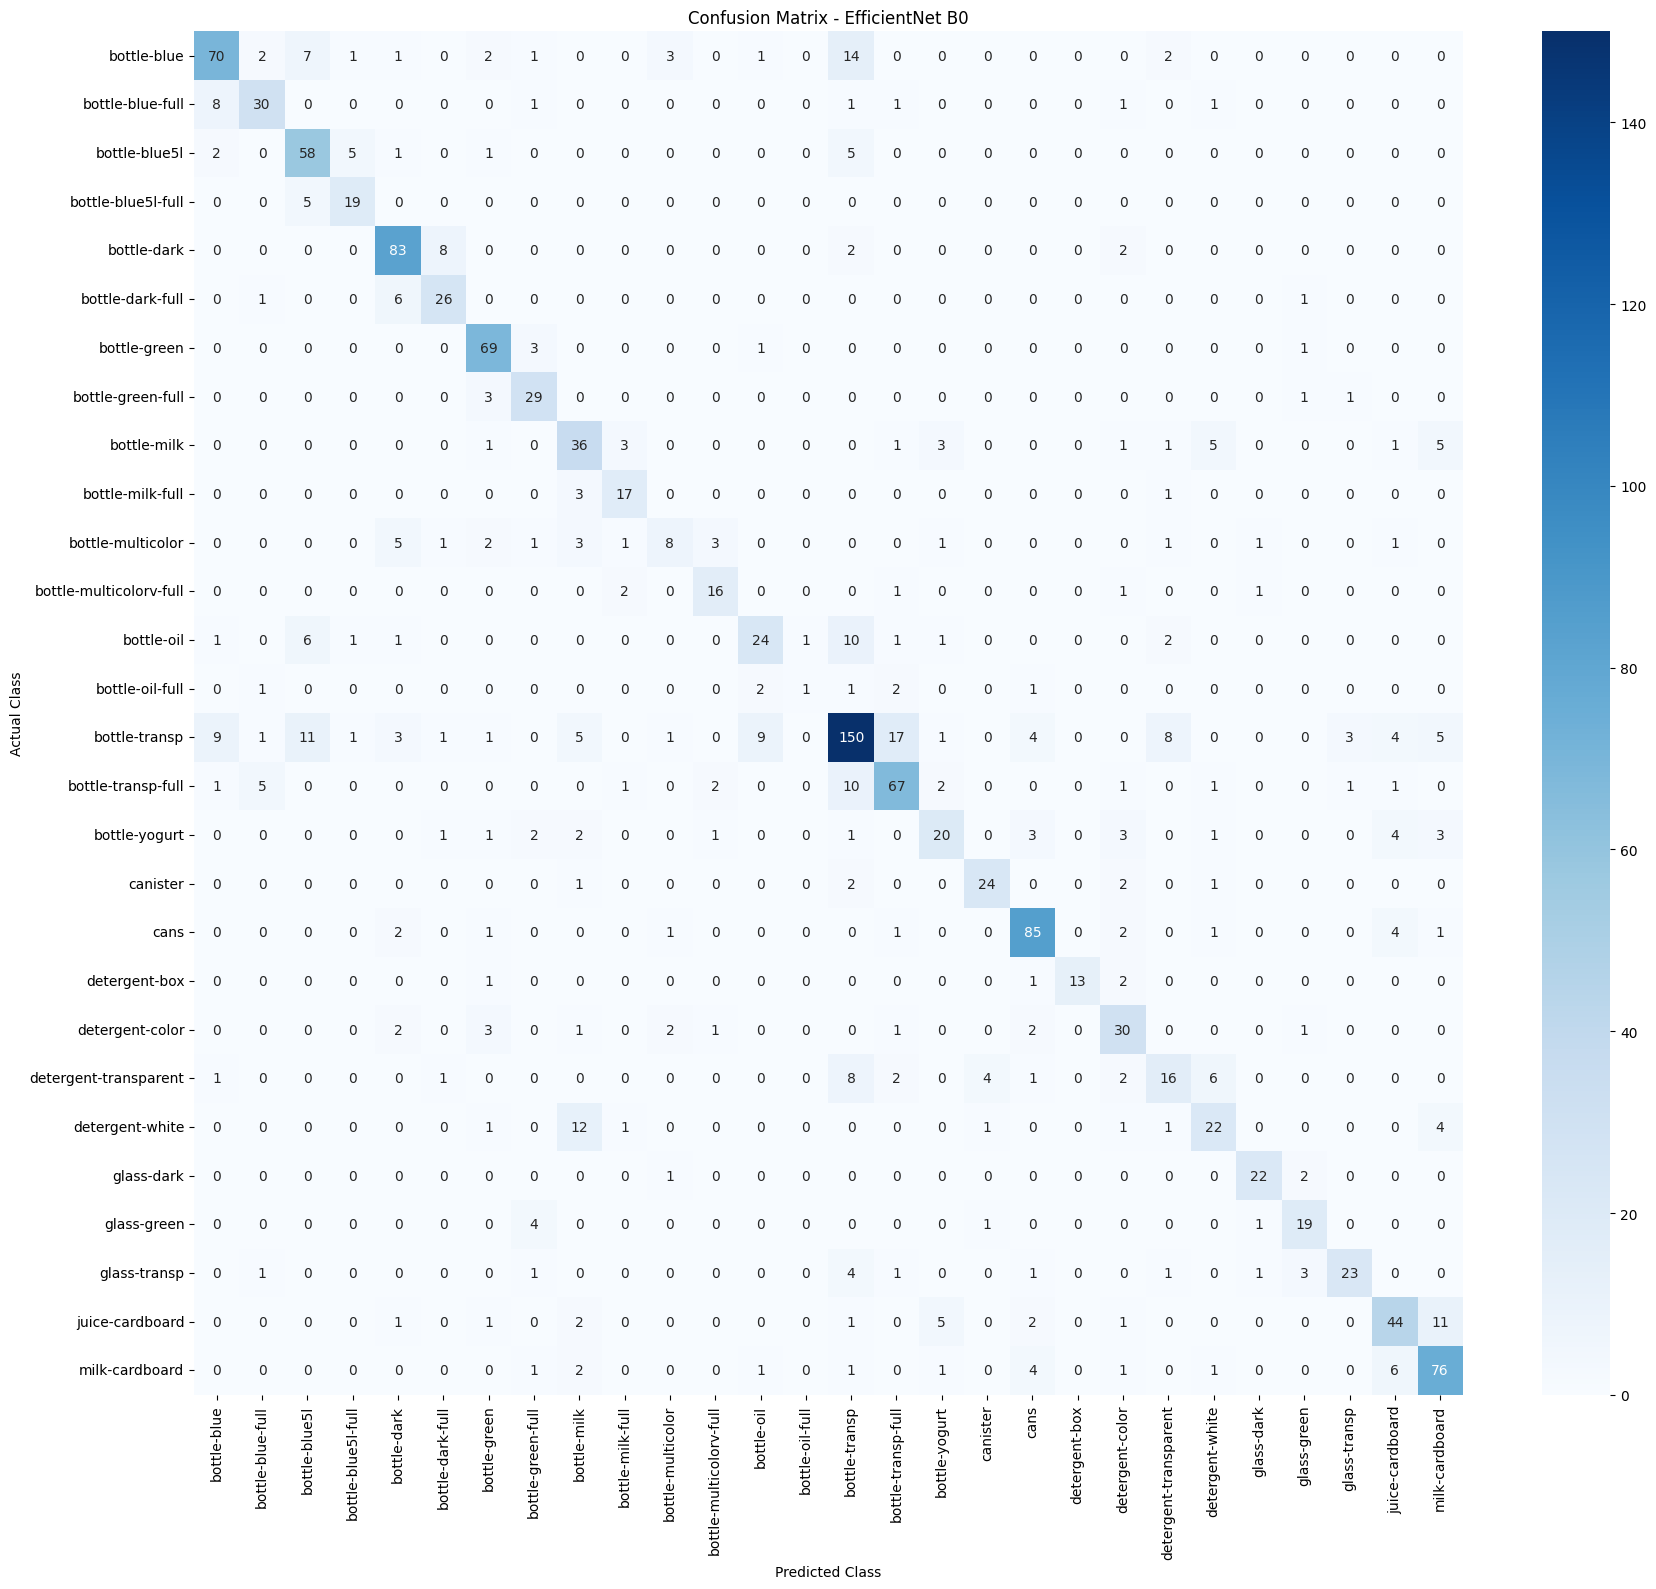

In [ ]:
# CONFUSION MATRIX
# Diagonal = correct predictions
# Off diagonal = mistakes

cm = confusion_matrix(test_labels1, test_preds1)

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes,
    cmap='Blues'
)
plt.title("Confusion Matrix - EfficientNet B0")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AML Project/confusion_efficientnet.png')
plt.show()